In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import xgboost as xgb
import json
import yaml
import hashlib
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.features.extract import load_feature_config, extract_features_from_flows, feature_config_hash_text
from src.pipeline.feature_pipeline import FeaturePipeline
from src.pipeline.artifacts import default_feature_artifacts
from src.models.xgb_train import train_xgboost
from src.eval.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support, confusion_matrix
from src.eval.plots import plot_roc_curves, plot_pr_curves, plot_confusion_matrices, plot_probability_distributions
from src.eval.evaluate import print_metrics_summary
from src.eval.calibration import fit_calibrator_from_df

paths = load_paths()
logger = setup_logger(level="INFO")

features_yaml = paths.configs_dir / "features.yaml"
cfg = load_feature_config(features_yaml)

logger.info("Re-extracting VNAT features...")
vnat_flows = pd.read_parquet(paths.data_processed / "vnat" / "flows.parquet")
vnat_feats = extract_features_from_flows(vnat_flows, cfg)
vnat_feats["dataset"] = "vnat" # Tag dataset

vnat_old = pd.read_parquet(paths.data_processed / "vnat" / "features_trainable.parquet")

split_map = dict(zip(vnat_old["capture_id"], vnat_old["split"]))
vnat_feats["split"] = vnat_feats["capture_id"].map(split_map).fillna("unknown")
vnat_feats = vnat_feats[vnat_feats["split"] != "unknown"].copy()

vnat_feats = vnat_feats[vnat_feats["q_min_packets_ok"] == 1.0].copy()
logger.info(f"VNAT features shape: {vnat_feats.shape}")

logger.info("Re-extracting ISCX features...")
iscx_flows = pd.read_parquet(paths.data_processed / "iscx" / "flows.parquet")
iscx_feats = extract_features_from_flows(iscx_flows, cfg)
iscx_feats["dataset"] = "iscx"

iscx_old = pd.read_parquet(paths.data_processed / "iscx" / "features.parquet")
split_map_iscx = dict(zip(iscx_old["capture_id"], iscx_old["split"]))
iscx_feats["split"] = iscx_feats["capture_id"].map(split_map_iscx).fillna("unknown")
iscx_feats = iscx_feats[iscx_feats["split"] != "unknown"].copy()

iscx_feats = iscx_feats[iscx_feats["q_min_packets_ok"] == 1.0].copy()
logger.info(f"ISCX features shape: {iscx_feats.shape}")

df_all = pd.concat([vnat_feats, iscx_feats], ignore_index=True)

df_all["split"] = df_all["split"].replace({
    "iscx_train": "train",
    "iscx_val": "val",
    "iscx_test": "test"
})

# --- REBALANCING VNAT SPLITS ---
logger.info("Rebalancing VNAT splits for robust evaluation...")
vnat_mask = df_all["dataset"] == "vnat"
vnat_df = df_all[vnat_mask].copy()
gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, temp_idx = next(gss.split(vnat_df, groups=vnat_df["capture_id"]))
vnat_train = vnat_df.iloc[train_idx]
vnat_temp = vnat_df.iloc[temp_idx]
gss_val_test = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss_val_test.split(vnat_temp, groups=vnat_temp["capture_id"]))
vnat_val = vnat_temp.iloc[val_idx]
vnat_test = vnat_temp.iloc[test_idx]
vnat_train["split"], vnat_val["split"], vnat_test["split"] = "train", "val", "test"
vnat_balanced = pd.concat([vnat_train, vnat_val, vnat_test])
df_all = pd.concat([df_all[~vnat_mask], vnat_balanced], ignore_index=True)


# --- MANUAL OVERRIDE: Fix Voipbuster Split ---
vb_train_cap = "vpn_vpn_voipbuster1a.pcap"
vb_test_cap = "vpn_vpn_voipbuster1b.pcap"
logger.info(f"Enforcing Voipbuster splits: {vb_train_cap} -> TRAIN, {vb_test_cap} -> TEST")
df_all.loc[df_all["capture_id"] == vb_train_cap, "split"] = "train"
df_all.loc[df_all["capture_id"] == vb_test_cap, "split"] = "test"

print("Final splits after rebalancing:\n", df_all["split"].value_counts())

# 4.5 Fit and Save Feature Pipeline
logger.info("Fitting and saving new FeaturePipeline...")
pipeline = FeaturePipeline().fit(df_all[df_all["split"] == "train"])
feature_art = default_feature_artifacts(paths.artifacts_dir / "features")
pipeline.save(feature_art, feature_config_hash=feature_config_hash_text(features_yaml))
logger.info(f"Pipeline saved. Model features: {len(pipeline.model_feature_names())}")

# 5. Train XGBoost
xgb_yaml = paths.configs_dir / "xgb.yaml"
res = train_xgboost(paths=paths, xgb_yaml=xgb_yaml, df=df_all)
print("\n--- Training Complete ---")
print_metrics_summary(res.metrics)

# 5.5 Calibrate
logger.info("Calibrating probabilities...")
df_preds = pd.read_parquet(res.preds_path)
calibrator = fit_calibrator_from_df(df_preds, prob_col="p_raw", fit_split="val")
df_preds["p_calib"] = calibrator.predict(df_preds["p_raw"].to_numpy())
df_preds.to_parquet(res.preds_path, index=False)
logger.info("Calibration complete.")


2026-02-26 15:34:13 | INFO | ai-vpn-firewall | Re-extracting VNAT features...
2026-02-26 15:34:47 | INFO | ai-vpn-firewall | VNAT features shape: (8107, 60)
2026-02-26 15:34:48 | INFO | ai-vpn-firewall | Re-extracting ISCX features...
2026-02-26 15:35:13 | INFO | ai-vpn-firewall | ISCX features shape: (4882, 60)
2026-02-26 15:35:13 | INFO | ai-vpn-firewall | Rebalancing VNAT splits for robust evaluation...
2026-02-26 15:35:13 | INFO | ai-vpn-firewall | Enforcing Voipbuster splits: vpn_vpn_voipbuster1a.pcap -> TRAIN, vpn_vpn_voipbuster1b.pcap -> TEST
Final splits after rebalancing:
 split
train    9428
val      2423
test     1138
Name: count, dtype: int64
2026-02-26 15:35:13 | INFO | ai-vpn-firewall | Fitting and saving new FeaturePipeline...
2026-02-26 15:35:13 | INFO | ai-vpn-firewall | Pipeline saved. Model features: 55
DEBUG mean/std (first 5):
[-0.  0. -0. -0. -0.]
[1. 1. 1. 1. 1.]
[0]	train-logloss:0.65434	train-auc:0.97383	train-aucpr:0.92546	val-logloss:0.67195	val-auc:0.86033	v

In [2]:
# 6. Advanced Firewall Evaluation
print("\n" + "="*60)
print("ADVANCED FIREWALL EVALUATION")
print("="*60)

# Load final predictions and metrics
df_preds = pd.read_parquet(res.preds_path)
metrics = res.metrics
test_preds = df_preds[df_preds["split"] == "test"].copy()

# Define thresholds from the metrics file (calculated on the VAL set)
# These keys are defined in `src/eval/metrics.py`
T_BLOCK = metrics["policy_thresholds"]["fpr_0_1pct"]["threshold"]
T_MONITOR = metrics["policy_thresholds"]["fpr_1pct"]["threshold"]
T_ALLOW = 0.0 # Anything below monitor is allowed

print(f"Policy Thresholds (from VAL set):")
print(f"  - BLOCK:   p >= {T_BLOCK:.4f} (Target FPR: 0.1%)")
print(f"  - MONITOR: p >= {T_MONITOR:.4f} (Target FPR: 1%)")
print(f"  - ALLOW:   p < {T_MONITOR:.4f}")

# --- 6.1 Flow-Level Triage Evaluation ---
print("\n--- [1] Flow-Level Triage Performance (on TEST set) ---")
y_true = test_preds["label"]
p_calib = test_preds["p_calib"]

# Block Zone Performance
y_hat_block = (p_calib >= T_BLOCK).astype(int)
prec_block, rec_block, f1_block, _ = precision_recall_fscore_support(y_true, y_hat_block, average="binary", zero_division=0)
tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_true, y_hat_block).ravel()

# Monitor Zone Performance (includes Blocked items)
y_hat_monitor = (p_calib >= T_MONITOR).astype(int)
prec_monitor, rec_monitor, f1_monitor, _ = precision_recall_fscore_support(y_true, y_hat_monitor, average="binary", zero_division=0)
tn_m, fp_m, fn_m, tp_m = confusion_matrix(y_true, y_hat_monitor).ravel()

print(f"\nBLOCK ZONE (p >= {T_BLOCK:.4f})")
print(f"  - Recall:    {rec_block:.4f}  (VPN flows correctly blocked)")
print(f"  - Precision: {prec_block:.4f}  (Of all blocked flows, this % were VPN)")
print(f"  - False Positives: {fp_b} flows")

print(f"\nMONITOR ZONE (p >= {T_MONITOR:.4f})")
print(f"  - Recall:    {rec_monitor:.4f}  (VPN flows correctly flagged for monitoring)")
print(f"  - Precision: {prec_monitor:.4f}")
print(f"  - False Positives: {fp_m} flows")

# --- 6.2 Session-Level Aggregation ---
print("\n--- [2] Session-Level Aggregation Performance (on TEST set) ---")
# A "session" is a capture_id. A session is positive if ANY flow is positive.
session_df = test_preds.groupby("capture_id").agg(
    session_score=("p_calib", "max"),
    session_label=("label", "max") # If any flow is 1, the session is 1
).reset_index()

y_true_sess = session_df["session_label"]
p_sess = session_df["session_score"]

# Session Block Performance
y_hat_sess_block = (p_sess >= T_BLOCK).astype(int)
prec_sess, rec_sess, f1_sess, _ = precision_recall_fscore_support(y_true_sess, y_hat_sess_block, average="binary", zero_division=0)
tn_s, fp_s, fn_s, tp_s = confusion_matrix(y_true_sess, y_hat_sess_block).ravel()

print("\nSESSION BLOCK (max(p) >= T_BLOCK)")
print(f"  - Recall:    {rec_sess:.4f}  (VPN *sessions* correctly blocked)")
print(f"  - Precision: {prec_sess:.4f}")
print(f"  - False Positive Sessions: {fp_s}")
print("  (This is the most powerful and realistic firewall metric)")

# --- 6.3 Voipbuster Case Study ---
print("\n--- [3] Voipbuster Case Study ---")
vb_mask = test_preds["capture_id"].str.contains("voipbuster")
vb_df = test_preds[vb_mask]

if len(vb_df) > 0:
    max_prob_vb = vb_df["p_calib"].max()
    print(f"Voipbuster Max Flow Probability: {max_prob_vb:.4f}")

    if max_prob_vb >= T_BLOCK:
        print("  - RESULT: BLOCKED at the session level.")
    elif max_prob_vb >= T_MONITOR:
        print("  - RESULT: FLAGGED for monitoring (but not blocked).")
    else:
        print("  - RESULT: ALLOWED (missed).")
else:
    print("Voipbuster not found in the rebalanced test set.")

print("\n" + "="*60)


ADVANCED FIREWALL EVALUATION
Policy Thresholds (from VAL set):
  - BLOCK:   p >= 0.9833 (Target FPR: 0.1%)
  - MONITOR: p >= 0.9386 (Target FPR: 1%)
  - ALLOW:   p < 0.9386

--- [1] Flow-Level Triage Performance (on TEST set) ---

BLOCK ZONE (p >= 0.9833)
  - Recall:    0.0000  (VPN flows correctly blocked)
  - Precision: 0.0000  (Of all blocked flows, this % were VPN)
  - False Positives: 0 flows

MONITOR ZONE (p >= 0.9386)
  - Recall:    0.3821  (VPN flows correctly flagged for monitoring)
  - Precision: 1.0000
  - False Positives: 0 flows

--- [2] Session-Level Aggregation Performance (on TEST set) ---

SESSION BLOCK (max(p) >= T_BLOCK)
  - Recall:    0.0000  (VPN *sessions* correctly blocked)
  - Precision: 0.0000
  - False Positive Sessions: 0
  (This is the most powerful and realistic firewall metric)

--- [3] Voipbuster Case Study ---
Voipbuster Max Flow Probability: 0.9400
  - RESULT: FLAGGED for monitoring (but not blocked).




--- Generating Plots ---


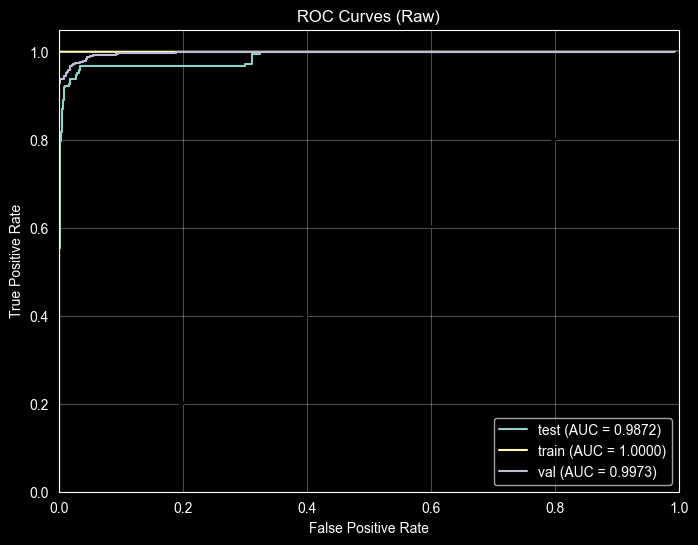

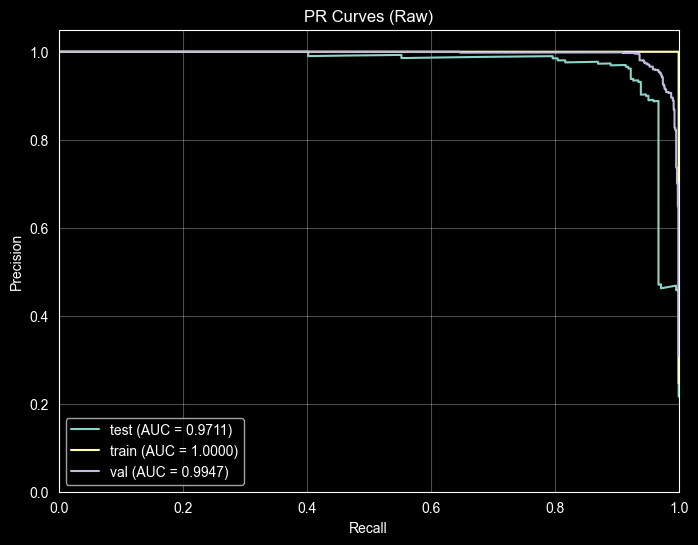

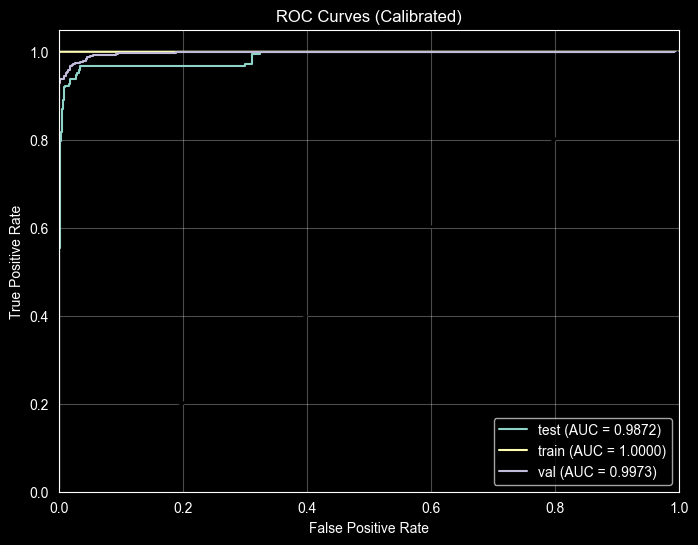

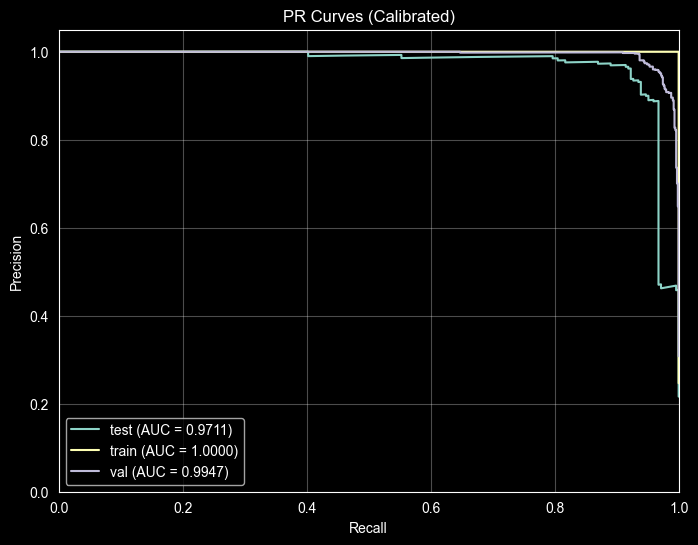

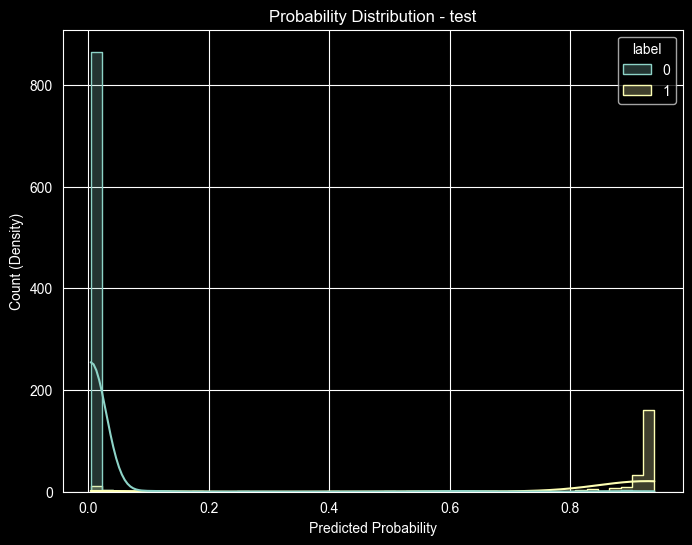

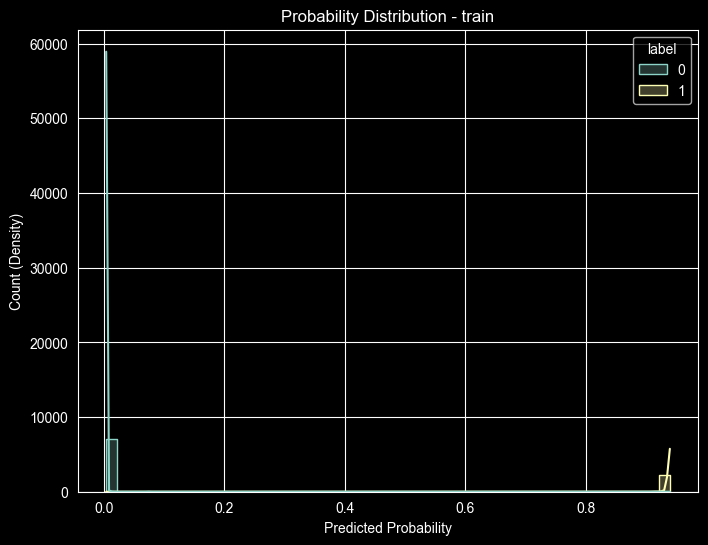

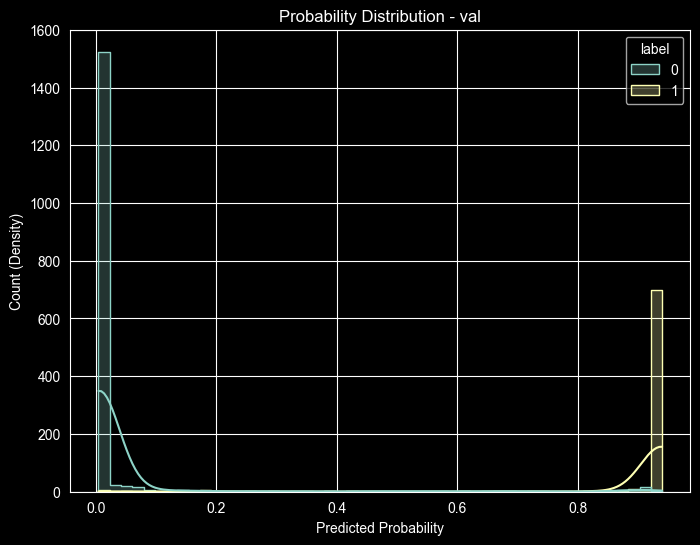

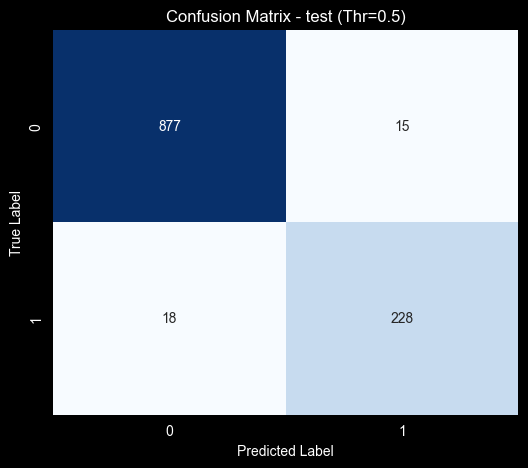

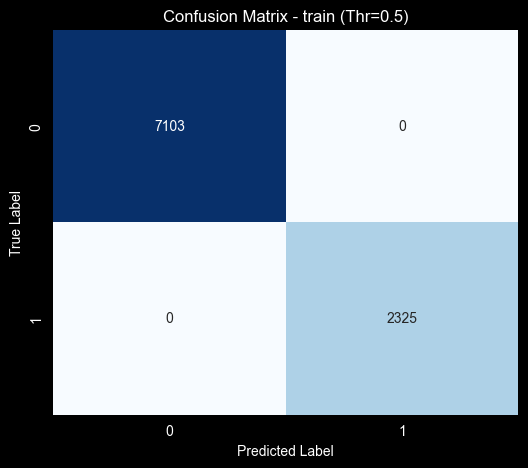

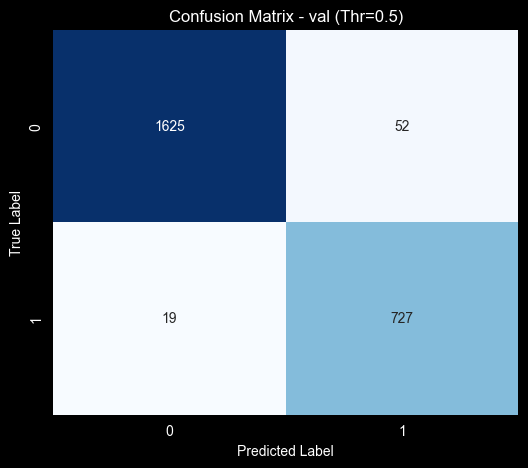

In [3]:
print("\n--- Generating Plots ---")
# Load predictions (now with p_calib)
df_preds = pd.read_parquet(res.preds_path)

plot_roc_curves(df_preds, prob_col="p_raw", title="ROC Curves (Raw)")
plot_pr_curves(df_preds, prob_col="p_raw", title="PR Curves (Raw)")

if "p_calib" in df_preds.columns:
    plot_roc_curves(df_preds, prob_col="p_calib", title="ROC Curves (Calibrated)")
    plot_pr_curves(df_preds, prob_col="p_calib", title="PR Curves (Calibrated)")
    plot_probability_distributions(df_preds, prob_col="p_calib")
    plot_confusion_matrices(df_preds, prob_col="p_calib", threshold=0.5)


In [4]:
print("\n--- Dataset Distribution Across Splits ---")
dist_table = df_all.groupby(["dataset", "split"]).size().unstack(fill_value=0)
print(dist_table)

print("\n--- Percentage Distribution ---")
pct_table = dist_table.div(dist_table.sum(axis=1), axis=0) * 100
print(pct_table.round(2))

if (dist_table == 0).any().any():
    print("\nWARNING: Some splits are empty for a dataset! This could lead to bias.")
else:
    print("\nCONFIRMED: Both datasets are present in all splits (Train/Val/Test).")


--- Dataset Distribution Across Splits ---
split    test  train   val
dataset                   
iscx      337   3614   931
vnat      801   5814  1492

--- Percentage Distribution ---
split    test  train    val
dataset                    
iscx     6.90  74.03  19.07
vnat     9.88  71.72  18.40

CONFIRMED: Both datasets are present in all splits (Train/Val/Test).
